## CitySeer: Métricas Configuracionais do Espaço Urbano

# Backend

Processamento interno do código. A princípio, o usuário não precisa se preocupar com esta parte, mas aqueles com conhecimento mais avançado de programação podem fazer ajustes de acordo com as próprias necessidades específicas.

In [9]:
# Standard library imports
import datetime as dt
import os
import pickle
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, List

# Third-party library imports
from cityseer.metrics import layers, networks
from cityseer.tools import graphs, io
from cityseer.rustalgos import graph
import contextily as cx
import geobr
import geopandas as gpd
from libpysal.cg import voronoi_frames
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
import partridge as ptg
from shapely.geometry import Point, LineString
from tobler.area_weighted import area_interpolate
from tqdm import tqdm


# --- imports -----------------------------------------------------------------
from __future__ import annotations

import math
from typing import List

import numpy as np
import geopandas as gpd
from shapely.geometry import LineString

In [10]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pd.options.display.float_format = '{:,.2f}'.format

In [11]:
MAIN_DATA = Path(os.environ.get('DB_FOLDER'))

FOLDER = os.environ.get('OUT_FOLDER')

DATABASE = Path(FOLDER)

OUT_DIR = Path(FOLDER) / 'B/cityseer'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [12]:
MUNI_CODES = 3106200,

# Getting Valid Study Area

In [13]:
place = pd.concat([
    geobr.read_municipality(idx)
    for idx in MUNI_CODES
])

crs = place.estimate_utm_crs(datum_name='SIRGAS 2000')
place = place.to_crs(crs)

study_area_bounds = place.geometry.squeeze()
study_buffer = place.geometry.convex_hull.squeeze().buffer(15000)

# Graph Prepation

In [14]:
OUT_PICKLE    = (
    OUT_DIR
    / f"simplified_graph.gpickle"
    )


#with open(OUT_PICKLE, 'wb') as f:
#    pickle.dump(G, f, pickle.HIGHEST_PROTOCOL)

with open(OUT_PICKLE, 'rb') as f:
    G = pickle.load(f)

In [15]:
for node_idx, node_data in G.nodes(data=True):
    node_pnt = Point(node_data["x"], node_data["y"])
    if node_pnt.intersects(study_area_bounds):
        G.nodes[node_idx]["live"] = True
    else:
        G.nodes[node_idx]["live"] = False

In [16]:
G_dual = graphs.nx_to_dual(G)

INFO:cityseer.tools.graphs:Converting graph to dual.
INFO:cityseer.tools.graphs:Preparing dual nodes
100%|██████████| 131314/131314 [00:06<00:00, 20870.93it/s]
INFO:cityseer.tools.graphs:Preparing dual edges (splitting and welding geoms)
100%|██████████| 131314/131314 [05:25<00:00, 403.72it/s]


In [17]:
# For mixed uses later on
nodes_gdf, _edges_gdf, network_structure = io.network_structure_from_nx(
    G_dual,
)

INFO:cityseer.tools.io:Preparing node and edge arrays from networkX graph.
100%|██████████| 131314/131314 [01:23<00:00, 1568.74it/s]
INFO:cityseer.graph:Edge R-tree built successfully with 292672 items.


# Graph Metrics

In [18]:
# Cutoffs from local to global
distances = [500, 1000, 1500, 2000, 2500, 5000]
#distances = [15_000]

## Weighted Measures

In [19]:
def get_node_weights(
    nodes: gpd.GeoDataFrame,
    gdf: gpd.GeoDataFrame,
    study_area: gpd.GeoDataFrame,
    attr_cols: List[str],
    out_crs: str | int = 31983
) -> pd.DataFrame:
    """
    Impute attributes from a GeoDataFrame to nodes in an OSMnx graph.

    Returns:
    - DataFrame with attr_cols, indexed as nodes
    """
    gdf, geom_types = validate_input_gdf(gdf, attr_cols)
    node_polygons = create_voronoi_polygons(nodes, study_area, out_crs)

    geometry_handlers = {
        frozenset({'Polygon', 'MultiPolygon'}): handle_polygons_with_area_interpolation,
        frozenset({'Point', 'MultiPoint'}): handle_points_with_spatial_join,
    }

    for geom_type_set, handler in geometry_handlers.items():
        if geom_types.issubset(geom_type_set):
            # Call the handler, but only keep attr_cols and index
            result = handler(nodes.copy(), gdf, node_polygons, attr_cols, out_crs)
            return result[attr_cols]

    raise ValueError("Tipo de geometria não suportado no GeoDataFrame.")


def validate_input_gdf(
    gdf: gpd.GeoDataFrame, attr_cols: List[str]
) -> tuple[gpd.GeoDataFrame, set[str]]:
    """Validate the input GeoDataFrame and attribute columns."""
    if gdf.empty:
        raise ValueError("O GeoDataFrame de entrada está vazio.")

    dropped_count = gdf.loc[gdf.geometry.isnull()].shape[0]
    if dropped_count > 0:
        print(
            f"Aviso: {dropped_count} geometria(s) foram descartadas por serem "
            "nulas."
        )
    gdf = gdf.loc[gdf.geometry.notnull()]
    gdf = gdf.fillna(0)
    geom_types = set(gdf.geometry.geom_type.unique())

    for col in attr_cols:
        gdf[col] = pd.to_numeric(gdf[col], errors="coerce")
        if gdf[col].isnull().any():
            invalid_entries = gdf.loc[gdf[col].isnull(), col]
            if not invalid_entries.empty:
                print(
                    f"Aviso: A coluna '{col}' contém entradas inválidas que "
                    f"não puderam ser convertidas para valores numéricos: "
                    f"{invalid_entries.tolist()}"
                )

    return gdf, geom_types


def create_voronoi_polygons(
    nodes: gpd.GeoDataFrame,
    study_area: gpd.GeoDataFrame,
    out_crs: str | int
) -> gpd.GeoDataFrame:
    """Create Voronoi polygons around nodes."""
    return voronoi_frames(
        nodes.to_crs(out_crs),
        clip=study_area,
        return_input=False,
        as_gdf=True,
    )


def handle_polygons_with_area_interpolation(
    nodes: gpd.GeoDataFrame,
    gdf: gpd.GeoDataFrame,
    node_polygons: gpd.GeoDataFrame,
    attr_cols: List[str],
    out_crs: str | int,
) -> gpd.GeoDataFrame:
    """Handle polygons using area interpolation."""
    interpolated = area_interpolate(
        source_df=gdf.to_crs(out_crs),
        target_df=node_polygons,
        extensive_variables=attr_cols,
        allocate_total=True,
    )
    for col in attr_cols:
        nodes[col] = interpolated[col].to_numpy()
    return nodes


def handle_points_with_spatial_join(
    nodes: gpd.GeoDataFrame,
    gdf: gpd.GeoDataFrame,
    node_polygons: gpd.GeoDataFrame,
    attr_cols: List[str],
    out_crs: str | int,
) -> gpd.GeoDataFrame:
    """Handle points using spatial join and dissolve."""
    gdf = gdf.to_crs(out_crs)
    joined = gpd.sjoin(node_polygons, gdf, how="left", predicate="contains")
    dissolved = joined.groupby(joined.index).agg(
        {col: "sum" for col in attr_cols}
    )
    for col in attr_cols:
        nodes[col] = dissolved[col].to_numpy()
    return nodes


In [20]:
input_path = (
    DATABASE
    / 'A/sociodemografia/sociodemografia.parquet'
    )
pop_by_hex = gpd.read_parquet(input_path).xs(key=2022, level='year').to_crs(31983)

pop_by_hex = pop_by_hex.to_crs(crs)

pop_by_hex['massa_salarial'] = pop_by_hex['domicilios'] * pop_by_hex['rendimento_medio']

In [21]:
input_path = (
    DATABASE
    / 'A/oportunidades/rais/rais_treated.parquet'
    )
rais = gpd.read_parquet(input_path)

rais = rais.query(
    'grupo_cnae not in ["T", "U"] and '
    '(sector != "business_services_secondary" or grupo_cnae == "P")'
)

rais = rais.dropna(subset=['cnae_2']) # just in case

In [22]:
node_data = {
    'osmid': list(G_dual.nodes()),
    'x': [data['x'] for node, data in G_dual.nodes(data=True)],
    'y': [data['y'] for node, data in G_dual.nodes(data=True)],
}
# Create node GeoDataFrame
node_gdf = gpd.GeoDataFrame(
    node_data,
    crs=31983,
    geometry=gpd.points_from_xy(node_data['x'], node_data['y'])
    )
node_gdf = node_gdf.set_index('osmid')

In [23]:
node_gdf['habitantes'] = get_node_weights(
    node_gdf.assign(primal_edge=lambda x: x.geometry.centroid),
    pop_by_hex,
    study_area_bounds.buffer(1_000),
    attr_cols=['habitantes'],
    out_crs=31983,
)

node_gdf['domicilios'] = get_node_weights(
    node_gdf.assign(primal_edge=lambda x: x.geometry.centroid),
    pop_by_hex,
    study_area_bounds.buffer(1_000),
    attr_cols=['domicilios'],
    out_crs=31983,
)

node_gdf['massa_salarial'] = get_node_weights(
    node_gdf.assign(primal_edge=lambda x: x.geometry.centroid),
    pop_by_hex,
    study_area_bounds.buffer(1_000),
    attr_cols=['massa_salarial'],
    out_crs=31983,
)

node_gdf['estabelecimentos'] = get_node_weights(
    node_gdf.assign(primal_edge=lambda x: x.geometry.centroid),
    rais.assign(estabelecimentos=1),
    study_area_bounds.buffer(1_000),
    attr_cols=['estabelecimentos'],
    out_crs=31983,
)

node_gdf['weight'] = node_gdf.domicilios

In [24]:
nbunch = {
    k: {'weight': v}
    for k, v in node_gdf.weight.to_dict().items()
    }

nx.set_node_attributes(
    G_dual,
    nbunch,
)

In [25]:
weighted_nodes_gdf, _weighted_edges_gdf, weighted_network_structure = io.network_structure_from_nx(
    G_dual,
)

INFO:cityseer.tools.io:Preparing node and edge arrays from networkX graph.
100%|██████████| 131314/131314 [01:22<00:00, 1588.34it/s]
INFO:cityseer.graph:Edge R-tree built successfully with 292672 items.


In [26]:
multi_di_graph = ox.graph_from_place(
    "Belo Horizonte, MG, Brazil",
    network_type="drive",
    simplify=True,
)

multi_di_graph = ox.add_edge_speeds(multi_di_graph)
multi_di_graph = ox.add_edge_travel_times(multi_di_graph)
multi_di_graph = ox.project_graph(multi_di_graph, to_crs=31983)

ox_edges = ox.graph_to_gdfs(multi_di_graph, nodes=False, edges=True)
ox_edges = ox_edges.explode('highway')

In [27]:
ox_edges = ox_edges.reindex(
    columns=[
        'osmid',
        'highway',
        'speed_kph',
        'geometry'
    ]
)

In [28]:
systra = gpd.read_file(MAIN_DATA / 'beaga/BaseViaria_RMBH/BaseViaria_RMBH.shp')
systra = systra.loc[systra.CAR.notnull() & (systra.CAR > 0)]
systra = systra.reindex(columns=[
    'ID', 'AVG_BUS_SP', 'VEL_MEDIA', 'DEF_VELOCI', 'DEF_VELOC1', 'DEF_VELOC1', 'geometry'
])
systra = systra.to_crs(31983)
systra = systra.loc[systra.geometry.intersects(study_area_bounds)]

In [29]:
# --- helpers: geometry + bearings --------------------------------------------
def _is_valid_line(g) -> bool:
    return (
        g is not None
        and not g.is_empty
        and g.geom_type in {"LineString", "MultiLineString"}
        and g.length > 0.0
    )


def _main_linestring(geom) -> LineString:
    if geom.geom_type == "LineString":
        return geom
    if geom.geom_type == "MultiLineString":
        parts = [ls for ls in geom.geoms if ls.length > 0.0]
        return max(parts, key=lambda ls: ls.length) if parts else LineString()
    return LineString()


def _bearing_deg(ls: LineString) -> float:
    if ls.is_empty or len(ls.coords) < 2:
        return float("nan")
    (x0, y0), (x1, y1) = ls.coords[0], ls.coords[-1]
    ang = math.degrees(math.atan2((x1 - x0), (y1 - y0)))
    return ang + 360.0 if ang < 0 else ang


def _circ_diff_deg(a: float, b: float) -> float:
    d = abs(a - b) % 360.0
    return d if d <= 180.0 else 360.0 - d


def _orient_agn_diff(a: float, b: float) -> float:
    return min(_circ_diff_deg(a, b), _circ_diff_deg(a, (b + 180.0) % 360.0))


# --- k-NN over GeoPandas .sindex ---------------------------------------------
def k_nearest_lines(
    geom, gdf_search: gpd.GeoDataFrame, sidx, k: int,
    search_radius: float | None = None,
) -> List[int]:
    """
    Return indices of the k nearest lines to 'geom' from gdf_search.
    Uses bbox sindex preselection, exact distances, optional radius.
    """
    if geom is None or geom.is_empty:
        return []

    minx, miny, maxx, maxy = geom.bounds
    if search_radius is not None:
        pad = float(search_radius)
        env = (minx - pad, miny - pad, maxx + pad, maxy + pad)
    else:
        env = (minx, miny, maxx, maxy)

    cand = list(sidx.intersection(env))
    if not cand:
        return []

    g = gdf_search.geometry.iloc[cand]
    d = g.distance(geom).to_numpy()

    if search_radius is not None:
        mask = d <= search_radius
        if not np.any(mask):
            return []
        cand = [cand[i] for i in np.flatnonzero(mask)]
        d = d[mask]

    k_eff = min(k, len(cand))
    order = np.argpartition(d, kth=k_eff - 1)[:k_eff]
    order = order[np.argsort(d[order])]
    return [cand[i] for i in order]


# --- full pipeline: radius + bearing + nearest -------------------------------
def impute_speed_line2line_gp(
    gdf_src: gpd.GeoDataFrame,
    gdf_tgt: gpd.GeoDataFrame,
    speed_col: str = "AVG_BUS_SP",
    search_radius_m: float = 50.0,
    bearing_tol_deg: float = 25.0,
    k_candidates: int = 12,
    min_len_m: float = 0.0,
) -> gpd.GeoDataFrame:
    """
    GeoPandas-only speed transfer:
      1) For each target, fetch k nearest source lines within radius R.
      2) Gate by orientation (Δθ with 180° symmetry) ≤ θ_tol.
      3) Pick the remaining candidate with minimum exact distance.
    """
    if speed_col not in gdf_src.columns:
        raise KeyError(f"'{speed_col}' missing in gdf_src.")

    if gdf_src.crs != gdf_tgt.crs:
        raise ValueError("CRS mismatch between gdf_src and gdf_tgt.")

    src = gdf_src.reset_index(drop=True).copy()
    tgt = gdf_tgt.reset_index(drop=True).copy()

    if min_len_m > 0.0:
        src = src[src.length >= min_len_m].reset_index(drop=True)
        tgt = tgt[tgt.length >= min_len_m].reset_index(drop=True)

    src_main = src.geometry.apply(_main_linestring)
    tgt_main = tgt.geometry.apply(_main_linestring)

    src_bear = np.array([_bearing_deg(ls) for ls in src_main], float)
    src_speed = np.array(src[speed_col].to_numpy(), float)

    sidx = src.sindex
    if sidx is None:
        raise RuntimeError("GeoDataFrame.sindex is unavailable.")

    out_speed = np.full(len(tgt), np.nan, float)
    out_dist = np.full(len(tgt), np.nan, float)
    out_dtht = np.full(len(tgt), np.nan, float)
    out_srci = np.full(len(tgt), -1, int)

    for i in range(len(tgt)):
        geom_t = tgt_main.iloc[i]
        if not _is_valid_line(geom_t):
            continue

        t_bear = _bearing_deg(geom_t)

        cand_idx = k_nearest_lines(
            geom_t, src, sidx, k=k_candidates,
            search_radius=search_radius_m,
        )
        if not cand_idx:
            continue

        # Enforce orientation gate, then pick nearest among those
        best_j, best_d, best_dt = None, float("inf"), float("inf")
        for j in cand_idx:
            geom_s = src_main.iloc[j]
            if not _is_valid_line(geom_s):
                continue
            dtheta = _orient_agn_diff(t_bear, src_bear[j])
            if dtheta > bearing_tol_deg:
                continue
            d = geom_t.distance(geom_s)
            if d < best_d:
                best_j, best_d, best_dt = j, d, dtheta

        if best_j is None:
            continue

        out_speed[i] = float(src_speed[best_j])
        out_dist[i] = best_d
        out_dtht[i] = best_dt
        out_srci[i] = best_j

    res = tgt.copy()
    res["speed_imputed"] = out_speed
    res["nearest_dist_m"] = out_dist
    res["dtheta_deg"] = out_dtht
    res["match_src_pos"] = out_srci
    return res


In [30]:
gdf_out = impute_speed_line2line_gp(
    systra.loc[systra.DEF_VELOCI == "Média GPS"],
    ox_edges,
    speed_col="AVG_BUS_SP",
    search_radius_m=50.0,
    bearing_tol_deg=25.0,
    k_candidates=5,
    min_len_m=5.0,  # optional: ignore tiny spurs
)


In [31]:
inpath = MAIN_DATA / 'beaga/origin_destination_survey/2012/malha_areas_homogeneas.zip'
zones = gpd.read_file(inpath).to_crs(31983)
zones = zones.astype({'AH2011': int}).astype({'AH2011': str})

zone_corresp = (
    gdf_out.centroid
    .to_frame('geometry')
    .sjoin(zones)
    .drop(columns=['index_right', 'geometry'])
    )

gdf_out = gdf_out.merge(
    zone_corresp,
    left_index=True,
    right_index=True,
    how='left',
    validate='1:1',
)

In [32]:
gdf_out['speed_imputed'] = (
    gdf_out
    .groupby(['AH2011', 'highway'])
    .speed_imputed
    .transform(
        lambda x: x.fillna(x.median())
        )
    ).drop(columns='AH2011')

In [33]:
gdf_out['speed_imputed'] = np.where(
    gdf_out['speed_imputed'] * 2 <= gdf_out.speed_kph,
    gdf_out['speed_imputed'] * 2,
    gdf_out.speed_kph
)

In [34]:
db = gdf_out
db.groupby('highway').speed_imputed.describe()

,count,mean,std,min,25%,50%,75%,max
highway,,,,,,,,
busway,152.00,38.59,5.30,29.88,34.65,38.35,41.65,60.00
crossing,6.00,29.74,0.00,29.74,29.74,29.74,29.74,29.74
dummy,2.00,32.41,0.00,32.41,32.41,32.41,32.41,32.41
escape,2.00,27.79,0.00,27.79,27.79,27.79,27.79,27.79
living_street,602.00,28.08,2.29,10.00,28.00,28.00,28.00,35.29
motorway,189.00,40.60,8.04,19.48,35.34,40.30,45.13,61.04
motorway_link,179.00,40.10,6.73,16.97,35.50,39.75,43.05,60.00
primary,"1,248.00",34.51,6.08,21.07,29.73,34.48,38.76,60.00
primary_link,209.00,34.72,5.61,24.01,28.79,36.67,40.62,40.62


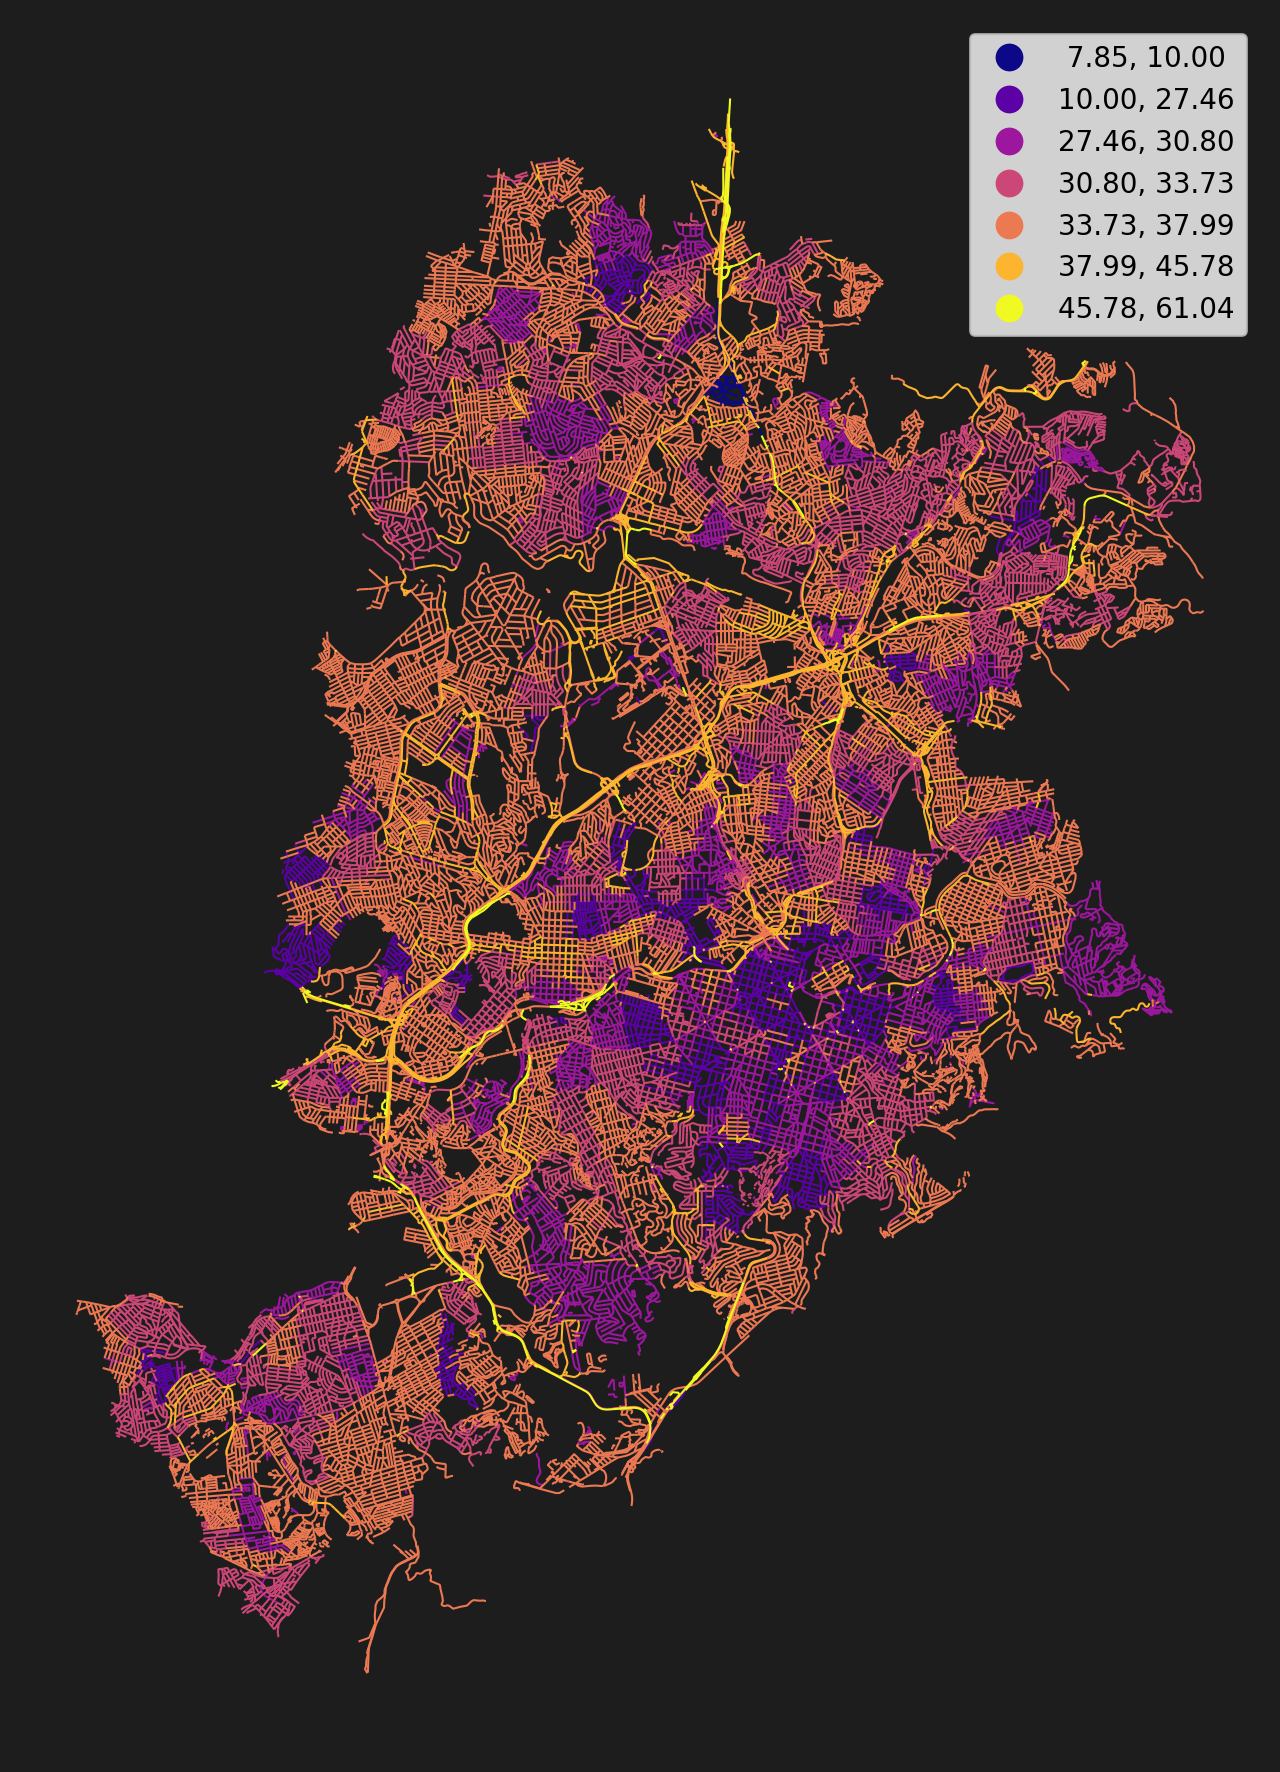

In [43]:
metric = "speed_imputed"

fig, ax = plt.subplots(1, 1, figsize=(8, 16), facecolor="#1d1d1d")
gdf_out.sort_values(metric).plot(
    column=metric,
    cmap="plasma",
    scheme='naturalbreaks',
    legend=True,
    ax=ax,
    linewidth=.75,
    k=7,
)

ax.axis(False)
plt.show()

In [36]:
gdf_out = impute_speed_line2line_gp(
    gdf_out,
    weighted_nodes_gdf,
    speed_col="speed_imputed",
    search_radius_m=50.0,
    bearing_tol_deg=25.0,
    k_candidates=5,
    min_len_m=5.0,  # optional: ignore tiny spurs
).drop(columns=['nearest_dist_m', 'dtheta_deg', 'match_src_pos',])


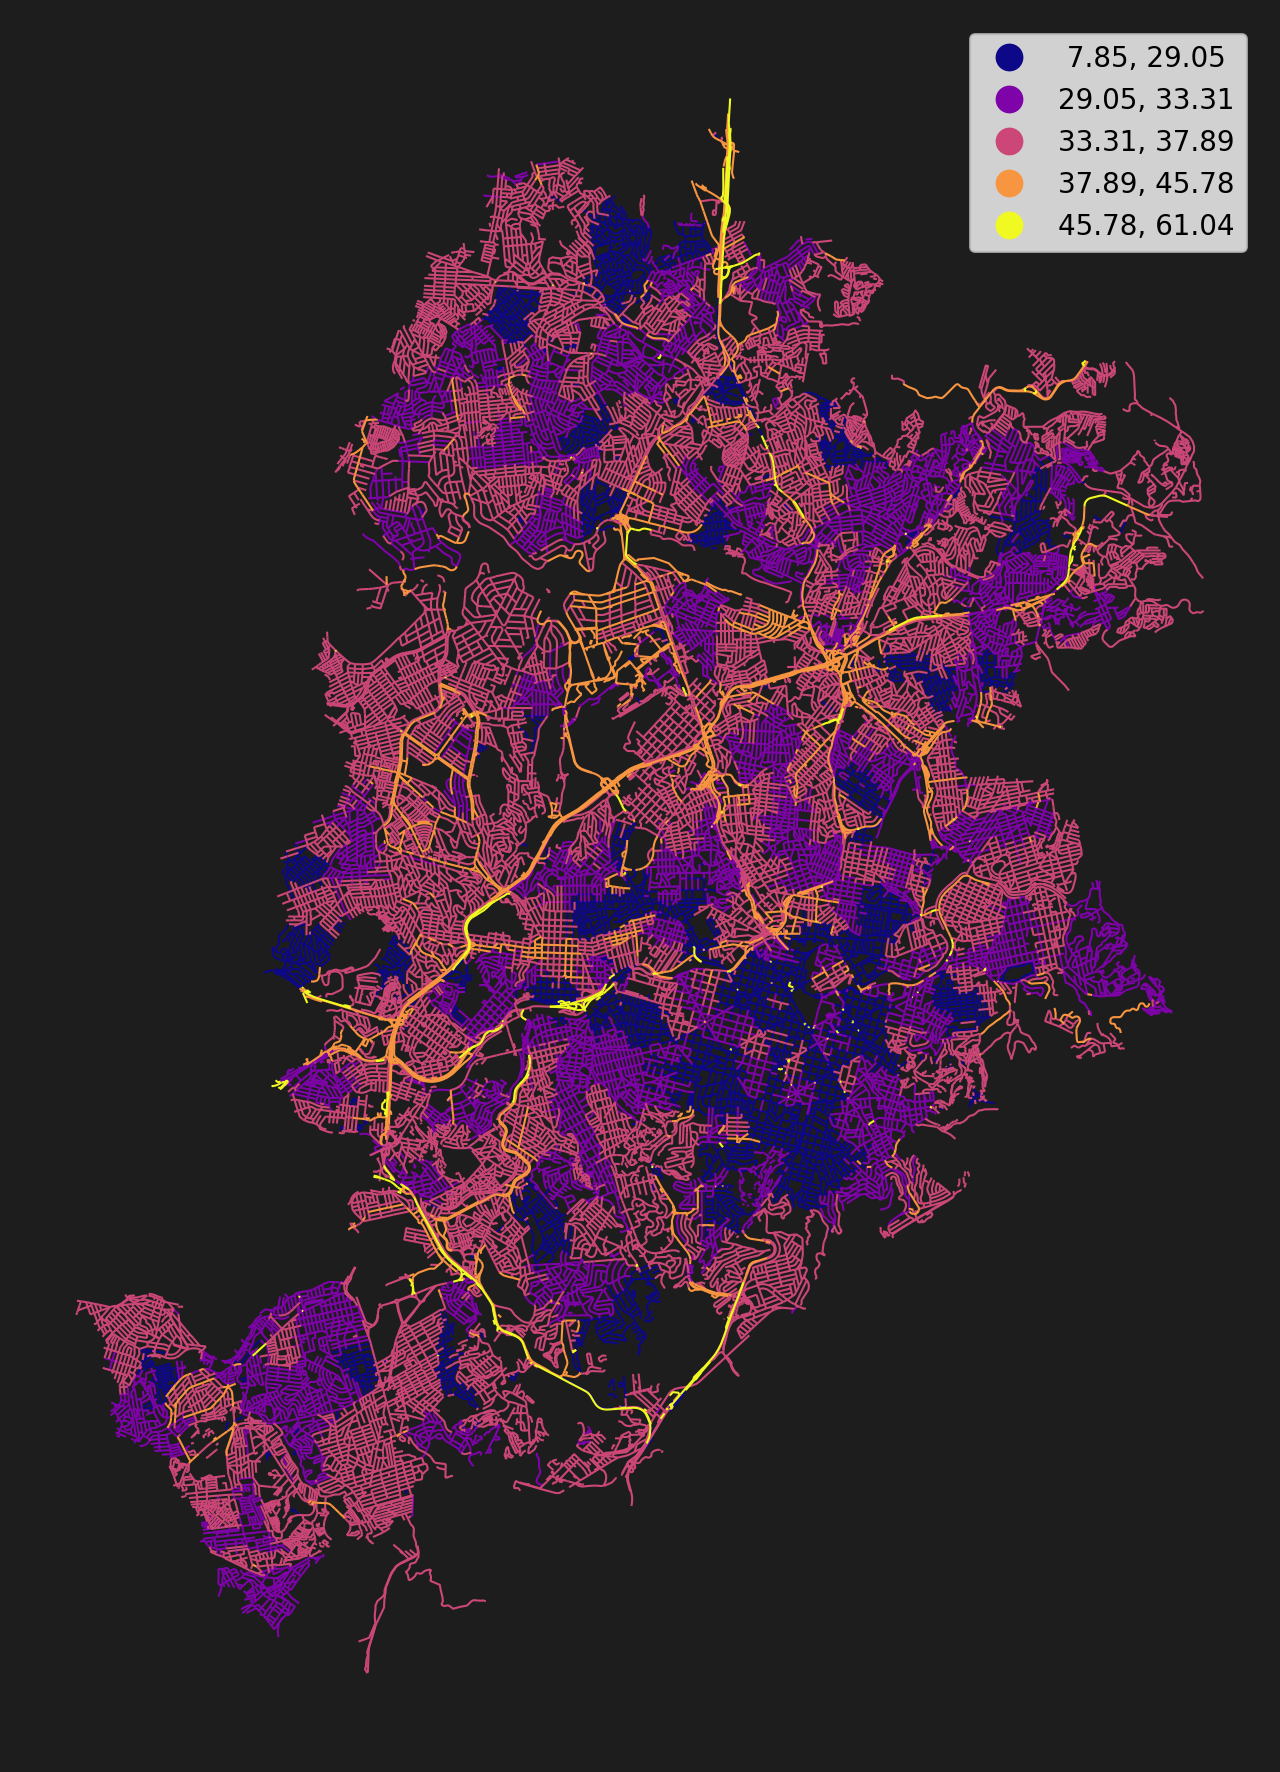

In [37]:
metric = "speed_imputed"

fig, ax = plt.subplots(1, 1, figsize=(8, 16), facecolor="#1d1d1d")
gdf_out.sort_values(metric).plot(
    column=metric,
    cmap="plasma",
    scheme='naturalbreaks',
    legend=True,
    ax=ax,
    linewidth=.75,
)

ax.axis(False)
plt.show()

In [38]:
foo = gdf_out.loc[gdf_out.live & gdf_out.speed_imputed.notnull(), ['primal_edge', 'speed_imputed']]


speeds_on_dual = _weighted_edges_gdf.sjoin_nearest(
    foo,
    how='left',
    max_distance=10,
    distance_col='dist_to_speed_source'
)

speeds_on_dual = speeds_on_dual.fillna({
    'speed_imputed': speeds_on_dual.speed_imputed.median()
    })

In [39]:
walk_m_s = 1.3333333333  # keep consistent with your metric calls

speeds_on_dual["speed_mps"] = speeds_on_dual["speed_imputed"] / 3.6
speeds_on_dual["imp_factor"] = walk_m_s / speeds_on_dual["speed_mps"]


In [40]:
records = [
    {
        "u": u,
        "v": v,
        "key": k,
        "geometry": data["geom"]
    }
    for u, v, k, data in G_dual.edges(keys=True, data=True)
]

edges_gdf = gpd.GeoDataFrame(
    pd.DataFrame(records),     # <-- pass as DataFrame
    geometry="geometry",       # <-- now specify geometry column
    crs=31983                   # your projected CRS
)


edges_joined = edges_gdf.sjoin_nearest(
    speeds_on_dual.drop(columns='index_right'), 
    distance_col="proj_dist",     # optional: store nearest distance
    max_distance=50            # optional: cap distance if desired
    
)


In [41]:
for row in edges_joined.itertuples():
    attrs = {'imp_factor': row.imp_factor}
    attrs["nearest_dist_m"] = row.proj_dist
    G_dual[row.u][row.v][row.key].update(attrs)

In [42]:
weighted_nodes_gdf, _weighted_edges_gdf, weighted_network_structure = io.network_structure_from_nx(
    G_dual,
)

INFO:cityseer.tools.io:Preparing node and edge arrays from networkX graph.
100%|██████████| 131314/131314 [01:26<00:00, 1513.39it/s]
INFO:cityseer.graph:Edge R-tree built successfully with 292672 items.


In [49]:
OUT_GDUAL_PICKLE = OUT_DIR / "G_dual_car_speeds.gpickle"

with open(OUT_GDUAL_PICKLE, "wb") as f:
    pickle.dump(edges_joined, f, pickle.HIGHEST_PROTOCOL)

print(f"Saved G_dual to {OUT_GDUAL_PICKLE}")

Saved G_dual to C:\Users\brand\OneDrive\Documentos\Coppe\thesis\outputs\B\cityseer\G_dual_car_speeds.gpickle


### Shortest Distance

In [35]:
weighted_nodes_gdf = networks.node_centrality_shortest(
    network_structure=weighted_network_structure,
    nodes_gdf=weighted_nodes_gdf,
    distances=distances,
)

INFO:cityseer.metrics.networks:Computing shortest path node centrality.
100%|██████████| 131314/131314 [1:31:08<00:00, 24.01it/s] 
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 1500m, Beta: 0.00267, Walking Time: 18.75 minutes.
INFO:cityseer.config:Distance: 2000m, Beta: 0.002, Walking Time: 25.0 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 5000m, Beta: 0.0008, Walking Time: 62.5 minutes.


### Angular Distances

In [36]:
weighted_nodes_gdf = networks.node_centrality_simplest(
    network_structure=weighted_network_structure,
    nodes_gdf=weighted_nodes_gdf,
    distances=distances,
)

INFO:cityseer.metrics.networks:Computing simplest path node centrality.
100%|██████████| 131314/131314 [01:47<00:00, 1226.32it/s]
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 500m, Beta: 0.008, Walking Time: 6.25 minutes.
INFO:cityseer.config:Distance: 1000m, Beta: 0.004, Walking Time: 12.5 minutes.
INFO:cityseer.config:Distance: 1500m, Beta: 0.00267, Walking Time: 18.75 minutes.
INFO:cityseer.config:Distance: 2000m, Beta: 0.002, Walking Time: 25.0 minutes.
INFO:cityseer.config:Distance: 2500m, Beta: 0.0016, Walking Time: 31.25 minutes.
INFO:cityseer.config:Distance: 5000m, Beta: 0.0008, Walking Time: 62.5 minutes.


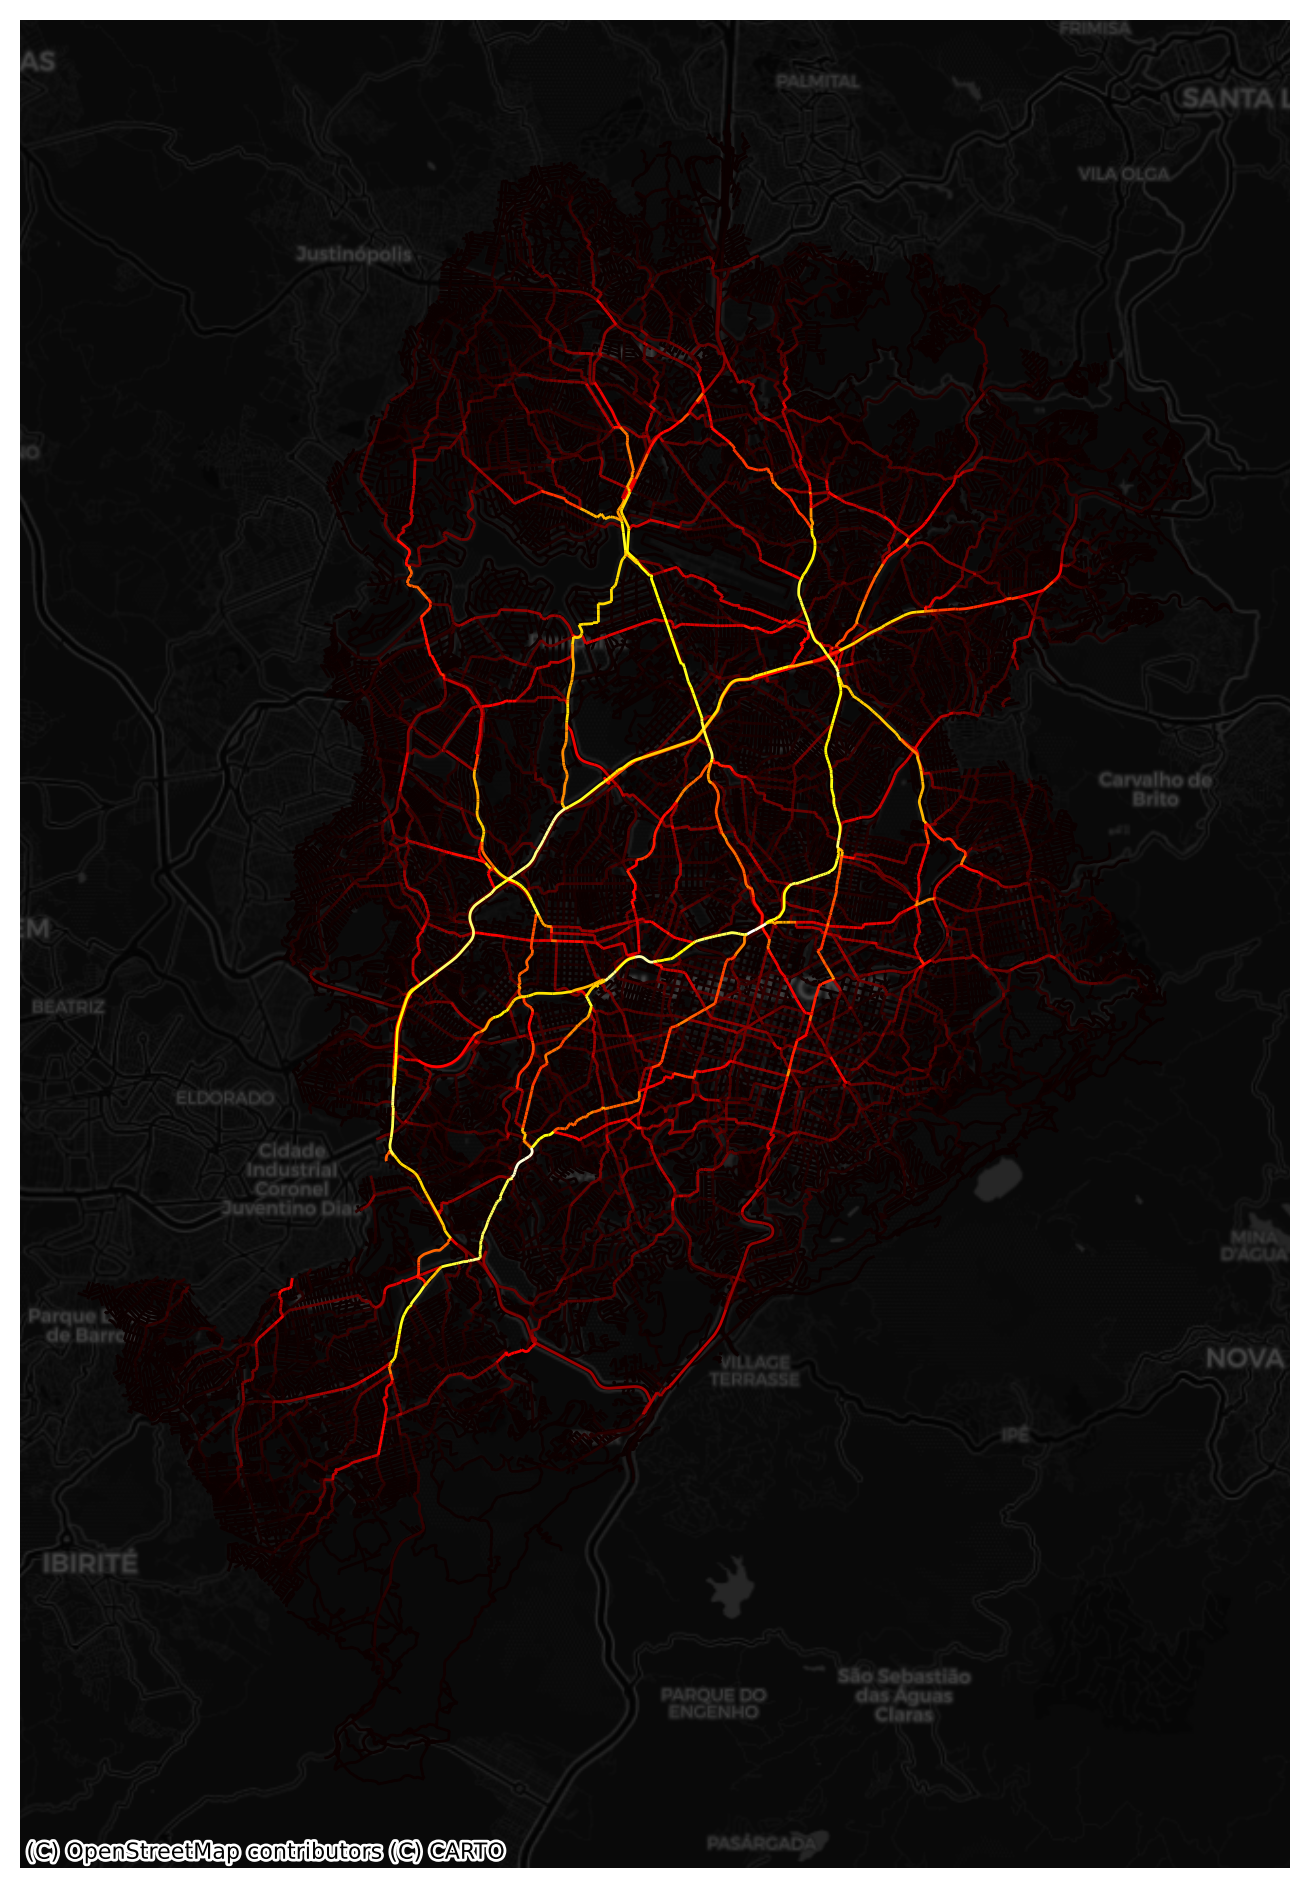

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12), facecolor="#FFFFFF")

metric = "cc_betweenness_2500"
db = weighted_nodes_gdf.query("live == True").sort_values(metric)

db.plot(
    column=metric,
    #cmap="PuBuGn",
    cmap="hot",
    #cmap='inferno',
    legend=False,
    #scheme='NaturalBreaks',
    ax=ax,
    linewidth=1,
)

ax.axis(False)
cx.add_basemap(
    ax=ax,
    crs=weighted_nodes_gdf.crs,
    source=cx.providers.CartoDB.DarkMatter,
)

plt.show()

In [38]:
OUT_PARQUET    = (
    OUT_DIR
    / f"car_weighted_centrality_by_population.parquet"
    )

weighted_nodes_gdf.to_parquet(
    OUT_PARQUET
)

#weighted_nodes_gdf = gpd.read_parquet(
#    OUT_PARQUET
#)

In [39]:
weighted_nodes_gdf

,ns_node_idx,x,y,live,weight,primal_edge,primal_edge_node_a,primal_edge_node_b,primal_edge_idx,dual_node,...,cc_farness_1500_ang,cc_farness_2000_ang,cc_farness_2500_ang,cc_farness_5000_ang,cc_betweenness_500_ang,cc_betweenness_1000_ang,cc_betweenness_1500_ang,cc_betweenness_2000_ang,cc_betweenness_2500_ang,cc_betweenness_5000_ang
4211387094_4211387106_k0,0,"599,754.27","7,766,843.12",False,0.00,"LINESTRING (599955.281 7766971.012, 599910.106...",4211387106,4211387094,0,POINT (599754.266676 7766843.121829),...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2058986487_964182464_k0,1,"597,349.77","7,767,635.03",False,0.00,"LINESTRING (596020.304 7768034.603, 596045.928...",964182464,2058986487,0,POINT (597349.770384 7767635.03143),...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2058791208_2379023556_k0,2,"597,613.79","7,768,431.80",False,0.00,"LINESTRING (597737.667 7768092.859, 597734.79 ...",2379023556,2058791208,0,POINT (597613.7891 7768431.796295),...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2058791208_7919676037_k0,3,"597,566.68","7,768,214.25",False,0.00,"LINESTRING (597444.998 7768384.977, 597467.722...",7919676037,2058791208,0,POINT (597566.677129 7768214.248412),...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2379023879_7803905793_k0,4,"598,601.09","7,767,343.16",False,0.00,"LINESTRING (598235.447 7767078.225, 598259.112...",7803905793,2379023879,0,POINT (598601.089432 7767343.160443),...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11835|92251±11835|92256_11835|92370±8976768654_k0,131309,"617,618.29","7,824,605.56",False,0.00,"LINESTRING (617671.917 7824655.879, 617564.667...",11835|92370±8976768654,11835|92251±11835|92256,0,POINT (617618.291966 7824605.564787),...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
7386437334±7386437336_7386437342±7386437343_k0,131310,"619,184.09","7,823,611.70",False,0.00,"LINESTRING (619240.836 7823519.58, 619127.345 ...",7386437342±7386437343,7386437334±7386437336,0,POINT (619184.090349 7823611.700585),...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
7386437342±7386437343_7386437353±7386437352_k0,131311,"619,069.72","7,823,797.36",False,0.00,"LINESTRING (619012.088 7823890.905, 619127.345...",7386437342±7386437343,7386437353±7386437352,0,POINT (619069.716658 7823797.363137),...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5879350845±8302019246_8302019247±8302019248_k0,131312,"619,875.22","7,823,359.07",False,0.00,"LINESTRING (619844.661 7823335.049, 619887.697...",5879350845±8302019246,8302019247±8302019248,0,POINT (619875.217222 7823359.070953),...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
